# Python 2: Data Analysis with pandas

Cushing/Whitney Medical Library — Yale University

## Workshop Notebook

Python 2 for Data Analysis:

- 10 minutes — Environment orientation, dataset introduction
- 35 minutes — Introduction to pandas: loading data, inspecting, selecting
- 40 minutes — Data cleaning & transformation
- 20 minutes — Grouping, aggregation & research questions
- 10 minutes — Bonus: seaborn visualization
- 5 minutes — Wrap-up & resources

## Welcome to Python 2!

In Python 1, we used Google Colab — a cloud-based notebook that handles everything for you. That's great for getting started, but professional data work happens on your own machine.

Today, you're graduating to a **local Python environment**. This is how researchers, data scientists, and developers actually work. You're using VS Code (or Positron) with a local Python installation and a virtual environment.

**Today's dataset**: We'll be working with the [OASIS-1](https://sites.wustl.edu/oasisbrains/) (Open Access Series of Imaging Studies) dataset — real MRI-derived data and demographics for 436 subjects used to study early-stage Alzheimer's Disease.

**Our goal**: Load, clean, and analyze this neuroscience dataset to answer a research question: *Does brain volume differ by dementia rating?*

# Introduction to pandas

## Why pandas?

In Python 1, we used **NumPy** to work with data. NumPy is great for purely numeric arrays — like our inflammation data — but real-world datasets have a mix of numbers, text, dates, and categories.

**pandas** is a library built on top of NumPy that handles this kind of mixed, tabular data. Think of it as Python's version of a spreadsheet, but much more powerful.

- [pandas documentation](https://pandas.pydata.org/docs/)
- [pandas 10-minute intro](https://pandas.pydata.org/docs/user_guide/10min.html)

In [1]:
import pandas as pd
# pandas is conventionally imported as 'pd'
# this is the same pattern we used with numpy: import numpy as np

## Loading Data

In Python 1, we loaded CSV files with `np.loadtxt()` — which required specifying the delimiter and only worked with numeric data. pandas makes this much simpler with `pd.read_csv()`. It automatically detects delimiters, handles mixed data types, and gives us column headers.

- [`read_csv()` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html)

In [2]:
df = pd.read_csv("data/oasis_cross-sectional.csv")
# 'df' is a common abbreviation for DataFrame — the primary pandas data structure

Let's take a look at our data. In a Jupyter notebook, we can just type the variable name to see it — no `print()` needed.

In [3]:
df

,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
431,OAS1_0285_MR2,M,R,20,NaN,NaN,NaN,NaN,1469,0.847,1.195,2.0
432,OAS1_0353_MR2,M,R,22,NaN,NaN,NaN,NaN,1684,0.790,1.042,40.0
433,OAS1_0368_MR2,M,R,22,NaN,NaN,NaN,NaN,1580,0.856,1.111,89.0
434,OAS1_0379_MR2,F,R,20,NaN,NaN,NaN,NaN,1262,0.861,1.390,2.0


## Inspecting the DataFrame

Before doing anything with data, we need to understand what we're working with. pandas provides several functions and attributes for this.

The `info()` function is usually the **first thing** you run after loading data. It tells you:
- How many rows and columns
- Column names and data types
- How many non-null (non-missing) values per column
- Memory usage

- [`info()` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.info.html)

In [4]:
df.info()

# Notice: some columns have fewer non-null values than others
# This tells us there's missing data — we'll deal with that later

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      436 non-null    object 
 1   M/F     436 non-null    object 
 2   Hand    436 non-null    object 
 3   Age     436 non-null    int64  
 4   Educ    235 non-null    float64
 5   SES     216 non-null    float64
 6   MMSE    235 non-null    float64
 7   CDR     235 non-null    float64
 8   eTIV    436 non-null    int64  
 9   nWBV    436 non-null    float64
 10  ASF     436 non-null    float64
 11  Delay   20 non-null     float64
dtypes: float64(7), int64(2), object(3)
memory usage: 41.0+ KB


Use `head()` and `tail()` to preview the first and last rows. By default they show 5 rows, but you can pass a number to see more.

- [`head()` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.head.html)
- [`tail()` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.tail.html)

In [5]:
df.head()

,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN


In [6]:
df.head(10)

# pass an integer to see that many rows

,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN
5,OAS1_0006_MR1,F,R,24,NaN,NaN,NaN,NaN,1131,0.862,1.551,NaN
6,OAS1_0007_MR1,M,R,21,NaN,NaN,NaN,NaN,1516,0.830,1.157,NaN
7,OAS1_0009_MR1,F,R,20,NaN,NaN,NaN,NaN,1505,0.843,1.166,NaN
8,OAS1_0010_MR1,M,R,74,5.0,2.0,30.0,0.0,1636,0.689,1.073,NaN
9,OAS1_0011_MR1,F,R,52,3.0,2.0,30.0,0.0,1321,0.827,1.329,NaN


In [7]:
df.tail()

,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
431,OAS1_0285_MR2,M,R,20,NaN,NaN,NaN,NaN,1469,0.847,1.195,2.0
432,OAS1_0353_MR2,M,R,22,NaN,NaN,NaN,NaN,1684,0.790,1.042,40.0
433,OAS1_0368_MR2,M,R,22,NaN,NaN,NaN,NaN,1580,0.856,1.111,89.0
434,OAS1_0379_MR2,F,R,20,NaN,NaN,NaN,NaN,1262,0.861,1.390,2.0
435,OAS1_0395_MR2,F,R,26,NaN,NaN,NaN,NaN,1283,0.834,1.368,39.0


We can also use **attributes** (no parentheses — just like `.shape` and `.dtype` in NumPy) to get quick facts about the DataFrame.

In [8]:
df.shape

# returns (rows, columns) — same syntax as numpy!

(436, 12)

In [9]:
df.columns

# lists all column names

Index(['ID', 'M/F', 'Hand', 'Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV',
       'nWBV', 'ASF', 'Delay'],
      dtype='object')

In [10]:
df.dtypes

# shows the data type of each column
# 'object' typically means text/string data
# 'float64' and 'int64' are numeric types

ID        object
M/F       object
Hand      object
Age        int64
Educ     float64
SES      float64
MMSE     float64
CDR      float64
eTIV       int64
nWBV     float64
ASF      float64
Delay    float64
dtype: object

## Selecting Data

Selecting specific rows, columns, or values is essential to exploring and transforming data. In Python 1, we used indexing with square brackets on lists and NumPy arrays. pandas selection works similarly but has some new behaviors.

### Selecting Columns

Use **single brackets** with a column name (as a string) to select one column. This returns a pandas **Series** — a single column of data.

In [11]:
df["Age"]

0      74
1      55
2      73
3      28
4      18
       ..
431    20
432    22
433    22
434    20
435    26
Name: Age, Length: 436, dtype: int64

In [12]:
type(df["Age"])

# a single column is a Series, not a DataFrame

pandas.core.series.Series

To select **multiple columns**, pass a **list** of column names — which means double brackets. The outer brackets are the selection, the inner brackets create the list.

In [13]:
df[["Age", "M/F", "CDR"]]

# double brackets: outer = selection, inner = list of column names

,Age,M/F,CDR
0,74,F,0.0
1,55,F,0.0
2,73,F,0.5
3,28,M,NaN
4,18,M,NaN
...,...,...,...
431,20,M,NaN
432,22,M,NaN
433,22,M,NaN
434,20,F,NaN


### Selecting Rows and Columns with `.loc[]`

`.loc[]` is the primary way to select data by **label** (column names and row index values). The syntax is:

```python
df.loc[row_selection, column_selection]
```

There is also `.iloc[]` which selects by **integer position** — you may see this online, but `.loc[]` is more intuitive for most research tasks and is what we'll use today.

- [`.loc[]` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.loc.html)
- [pandas indexing guide](https://pandas.pydata.org/docs/user_guide/indexing.html)

In [14]:
df.loc[0]

# select a single row by its index label

ID       OAS1_0001_MR1
M/F                  F
Hand                 R
Age                 74
Educ               2.0
SES                3.0
MMSE              29.0
CDR                0.0
eTIV              1344
nWBV             0.743
ASF              1.306
Delay              NaN
Name: 0, dtype: object

In [15]:
df.loc[0:4, ["Age", "M/F", "nWBV"]]

# select rows 0-4 and specific columns
# note: unlike Python slicing, loc includes the endpoint (row 4)

,Age,M/F,nWBV
0,74,F,0.743
1,55,F,0.810
2,73,F,0.708
3,28,M,0.803
4,18,M,0.848


### Filtering with Boolean Conditions

One of the most powerful features of `.loc[]` is filtering rows based on conditions. This is similar to the `if` statements we used in Python 1, but applied across an entire column at once.

In [16]:
df.loc[df["Age"] > 60]

# show only rows where Age is greater than 60

,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
8,OAS1_0010_MR1,M,R,74,5.0,2.0,30.0,0.0,1636,0.689,1.073,NaN
11,OAS1_0013_MR1,F,R,81,5.0,2.0,30.0,0.0,1664,0.679,1.055,NaN
13,OAS1_0015_MR1,M,R,76,2.0,NaN,28.0,0.5,1738,0.719,1.010,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
411,OAS1_0453_MR1,F,R,70,1.0,4.0,29.0,0.5,1295,0.748,1.355,NaN
412,OAS1_0454_MR1,F,R,73,3.0,2.0,23.0,0.5,1536,0.730,1.142,NaN
413,OAS1_0455_MR1,F,R,61,2.0,4.0,28.0,0.0,1354,0.825,1.297,NaN
414,OAS1_0456_MR1,M,R,61,5.0,2.0,30.0,0.0,1637,0.780,1.072,NaN


In [17]:
df.loc[df["Age"] > 60, ["Age", "M/F", "CDR", "nWBV"]]

# filter rows AND select specific columns
# this is a common pattern: "show me these columns for subjects over 60"

,Age,M/F,CDR,nWBV
0,74,F,0.0,0.743
2,73,F,0.5,0.708
8,74,M,0.0,0.689
11,81,F,0.0,0.679
13,76,M,0.5,0.719
...,...,...,...,...
411,70,F,0.5,0.748
412,73,F,0.5,0.730
413,61,F,0.0,0.825
414,61,M,0.0,0.780


## Summary Statistics

The `describe()` function provides summary statistics for all numeric columns at once — count, mean, standard deviation, min, max, and quartiles.

- [`describe()` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html)

In [18]:
df.describe()

# summary statistics for all numeric columns
# notice the 'count' row — it shows how many non-null values each column has

,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
count,436.000000,235.000000,216.000000,235.00000,235.000000,436.000000,436.000000,436.000000,20.00000
mean,51.357798,3.178723,2.490741,27.06383,0.285106,1481.919725,0.791670,1.198894,20.55000
std,25.269862,1.311510,1.120593,3.69687,0.383405,158.740866,0.059937,0.128682,23.86249
min,18.000000,1.000000,1.000000,14.00000,0.000000,1123.000000,0.644000,0.881000,1.00000
25%,23.000000,2.000000,2.000000,26.00000,0.000000,1367.750000,0.742750,1.111750,2.75000
50%,54.000000,3.000000,2.000000,29.00000,0.000000,1475.500000,0.809000,1.190000,11.00000
75%,74.000000,4.000000,3.000000,30.00000,0.500000,1579.250000,0.842000,1.284250,30.75000
max,96.000000,5.000000,5.000000,30.00000,2.000000,1992.000000,0.893000,1.563000,89.00000


# Data Cleaning

Most data scientists say that data cleaning takes up to 80% of their work. While that may be a slight exaggeration, the point stands: real-world data is messy, and preparing it for analysis is time-consuming but essential.

Here's our cleaning plan for the OASIS data:
- [ ] Identify and understand missing data patterns
- [ ] Drop columns we won't analyze
- [ ] Handle missing values (dropna vs. fillna)
- [ ] Explore values in categorical columns
- [ ] Rename columns for readability
- [ ] Convert data types where needed
- [ ] Save the cleaned dataset

## Understanding Missing Data

In pandas, missing data is represented as `NaN` (Not a Number). The `isna()` function returns `True` for missing values, and chaining it with `sum()` counts them per column.

- [`isna()` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.isna.html)
- [Working with missing data guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/missing_data.html)

In [19]:
df.isna().sum()

# this is the inverse of info() — instead of showing non-null counts, it shows NaN counts

ID         0
M/F        0
Hand       0
Age        0
Educ     201
SES      220
MMSE     201
CDR      201
eTIV       0
nWBV       0
ASF        0
Delay    416
dtype: int64

**What does this pattern tell us?**

Notice that `Educ`, `SES`, `MMSE`, and `CDR` all have about 200 missing values — and the dataset has 436 rows. This isn't random! The OASIS study included young healthy controls (ages 18-34) who didn't receive clinical cognitive assessments. Those columns are `NaN` because those tests weren't administered, not because the data was lost.

The `Delay` column has 416 NaN values out of 436 — it's almost entirely empty. This column tracks delay between repeat visits, which doesn't apply to most subjects in this cross-sectional study.

Understanding *why* data is missing is just as important as knowing *that* it's missing.

## Dropping Columns and Rows

The `drop()` function lets us remove rows or columns we don't need. We'll drop `Delay` (almost entirely NaN) and `Hand` (all subjects are right-handed — no variation to analyze).

**Important**: pandas operations don't change your data unless you assign the result back to a variable. `df.drop(...)` creates a new DataFrame — you need `df = df.drop(...)` to save the change.

- [`drop()` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html)

In [20]:
df = df.drop(columns=["Delay", "Hand"])

In [21]:
df.info()

# verify: we should now have 10 columns instead of 12

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      436 non-null    object 
 1   M/F     436 non-null    object 
 2   Age     436 non-null    int64  
 3   Educ    235 non-null    float64
 4   SES     216 non-null    float64
 5   MMSE    235 non-null    float64
 6   CDR     235 non-null    float64
 7   eTIV    436 non-null    int64  
 8   nWBV    436 non-null    float64
 9   ASF     436 non-null    float64
dtypes: float64(6), int64(2), object(2)
memory usage: 34.2+ KB


## Handling Missing Values: `dropna()` vs. `fillna()`

This is one of the most important decisions in data cleaning. You have two main options:

1. **`dropna()`** — Remove rows that contain missing values. Simple, but you lose data.
2. **`fillna()`** — Replace missing values with something (a number, a string, a calculated value). Preserves data, but you're making assumptions.

For our analysis, we want to study brain volume in relation to dementia ratings — so we need the `CDR` and `nWBV` columns to be complete. We'll use `dropna()` to remove rows where clinical data is missing.

We'll save the result to a **new variable** (`df_clinical`) so we still have our original data if we need it.

- [`dropna()` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dropna.html)
- [`fillna()` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html)

In [22]:
df_clinical = df.dropna()

# by default, dropna() removes any row that has ANY missing value

In [23]:
df_clinical.shape

# we went from 436 to 216 rows — we lost about half the data!
# that's the trade-off with dropna()

(216, 10)

In [24]:
df_clinical.info()

# confirm: all columns now show 216 non-null — no more missing data

<class 'pandas.core.frame.DataFrame'>
Index: 216 entries, 0 to 415
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      216 non-null    object 
 1   M/F     216 non-null    object 
 2   Age     216 non-null    int64  
 3   Educ    216 non-null    float64
 4   SES     216 non-null    float64
 5   MMSE    216 non-null    float64
 6   CDR     216 non-null    float64
 7   eTIV    216 non-null    int64  
 8   nWBV    216 non-null    float64
 9   ASF     216 non-null    float64
dtypes: float64(6), int64(2), object(2)
memory usage: 18.6+ KB


In [25]:
df_clinical.isna().sum()

# double check: all zeros — no missing values remain

ID      0
M/F     0
Age     0
Educ    0
SES     0
MMSE    0
CDR     0
eTIV    0
nWBV    0
ASF     0
dtype: int64

## Exploring Values in Columns

Now that our data is clean, let's explore what's in our categorical columns. Two useful functions:

- `unique()` — returns an array of distinct values
- `value_counts()` — returns counts of each unique value, sorted from most to least common

- [`unique()` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.unique.html)
- [`value_counts()` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.value_counts.html)

In [26]:
df_clinical["M/F"].value_counts()

M/F
F    145
M     71
Name: count, dtype: int64

In [27]:
df_clinical["CDR"].value_counts()

CDR
0.0    133
0.5     57
1.0     24
2.0      2
Name: count, dtype: int64

In [28]:
df_clinical["CDR"].unique()

# CDR values: 0.0 = no dementia, 0.5 = very mild, 1.0 = mild, 2.0 = moderate

array([0. , 0.5, 1. , 2. ])

## Renaming Columns

Column names like `M/F` and `nWBV` aren't very descriptive. The `rename()` function takes a dictionary where keys are old names and values are new names.

- [`rename()` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rename.html)

In [29]:
df_clinical = df_clinical.rename(columns={
    "M/F": "Gender",
    "nWBV": "BrainVolume"
})

In [30]:
df_clinical.columns

# verify the rename worked

Index(['ID', 'Gender', 'Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV',
       'BrainVolume', 'ASF'],
      dtype='object')

## Converting Data Types

Look at the `CDR` column — its values are 0.0, 0.5, 1.0, and 2.0. pandas treats these as floats (continuous numbers), but they're really **categories** — discrete dementia ratings, not measurements on a continuous scale.

If we leave CDR as a float, plotting tools might treat it as a continuous axis (showing 0.0, 0.1, 0.2, ...) instead of discrete groups. Converting it to a string fixes this.

- [`astype()` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.astype.html)

In [31]:
df_clinical["CDR"] = df_clinical["CDR"].astype(str)

# convert CDR from float to string so it's treated as a category

In [32]:
df_clinical["CDR"].value_counts()

# now CDR values display as strings: '0.0', '0.5', '1.0', '2.0'

CDR
0.0    133
0.5     57
1.0     24
2.0      2
Name: count, dtype: int64

In [33]:
df_clinical.info()

# notice CDR is now 'object' type (string) instead of 'float64'

<class 'pandas.core.frame.DataFrame'>
Index: 216 entries, 0 to 415
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           216 non-null    object 
 1   Gender       216 non-null    object 
 2   Age          216 non-null    int64  
 3   Educ         216 non-null    float64
 4   SES          216 non-null    float64
 5   MMSE         216 non-null    float64
 6   CDR          216 non-null    object 
 7   eTIV         216 non-null    int64  
 8   BrainVolume  216 non-null    float64
 9   ASF          216 non-null    float64
dtypes: float64(5), int64(2), object(3)
memory usage: 18.6+ KB


## Saving Your Work

After cleaning, save the result to a new CSV so you don't have to repeat the cleaning steps next time. The `index=False` parameter prevents pandas from writing the row index as an extra column.

pandas can also write to Excel (`.to_excel()`), JSON (`.to_json()`), and [many other formats](https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html).

- [`to_csv()` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_csv.html)

In [34]:
df_clinical.to_csv("data/oasis_cleaned.csv", index=False)

# Asking Research Questions with groupby

All that cleaning was in service of this moment — now we can ask the data a question.

The `groupby()` function splits your data into groups based on a column's values, then lets you apply aggregation functions (mean, count, sum, etc.) to each group. This is called the **split-apply-combine** pattern:

1. **Split** the data into groups (by CDR rating)
2. **Apply** a function to each group (calculate the mean)
3. **Combine** the results into a summary table

- [`groupby()` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.groupby.html)
- [groupby user guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html)

### Research Question: Does brain volume differ by dementia rating?

In [35]:
df_clinical.groupby("CDR")["BrainVolume"].mean()

# brain volume (nWBV) decreases as CDR increases
# this is consistent with Alzheimer's research — brain atrophy accompanies dementia

CDR
0.0    0.769188
0.5    0.728175
1.0    0.705500
2.0    0.684000
Name: BrainVolume, dtype: float64

Let's ask another question using the same pattern.

In [36]:
df_clinical.groupby("CDR")["Age"].mean()

# average age also increases with CDR — dementia is more common in older subjects

CDR
0.0    69.233083
0.5    77.070175
1.0    78.458333
2.0    82.000000
Name: Age, dtype: float64

### Aggregating Multiple Columns at Once

The `.agg()` function lets you calculate different statistics for different columns in a single call. Pass it a dictionary where keys are column names and values are the aggregation functions to apply.

In [37]:
df_clinical.groupby("CDR").agg({
    "BrainVolume": "mean",
    "Age": "mean",
    "MMSE": "mean"
})

# a summary table answering multiple questions at once
# MMSE (cognitive test score) also decreases with higher CDR

,BrainVolume,Age,MMSE
CDR,,,
0.0,0.769188,69.233083,29.097744
0.5,0.728175,77.070175,25.877193
1.0,0.705500,78.458333,21.958333
2.0,0.684000,82.000000,15.000000


In [38]:
df_clinical.groupby("Gender")["BrainVolume"].mean()

# we can group by any categorical column

Gender
F    0.755262
M    0.740775
Name: BrainVolume, dtype: float64

### Quick Visualization from Grouped Data

pandas has built-in plotting via `.plot()` that creates quick charts directly from DataFrames and Series. This uses matplotlib under the hood.

- [`plot()` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html)

<Axes: title={'center': 'Dementia Rating Distribution'}, xlabel='CDR'>

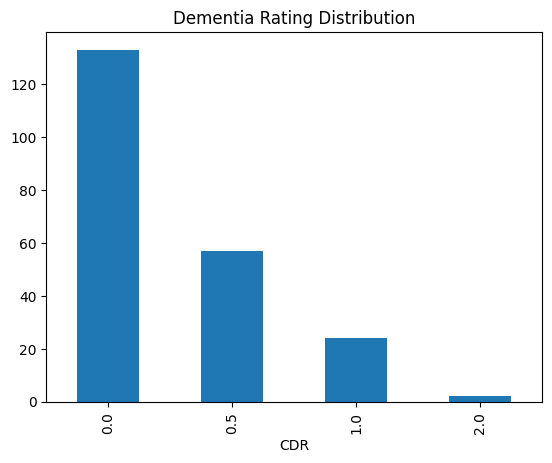

In [39]:
df_clinical["CDR"].value_counts().plot.bar(title="Dementia Rating Distribution")

# Bonus: Visualization with seaborn

**seaborn** is a statistical visualization library built on top of matplotlib. It's designed to work directly with pandas DataFrames and makes attractive, informative plots with minimal code.

- [seaborn documentation](https://seaborn.pydata.org/)
- [seaborn gallery](https://seaborn.pydata.org/examples/index.html)

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
# seaborn is conventionally imported as 'sns'
# we import matplotlib too for plt.show() and customization

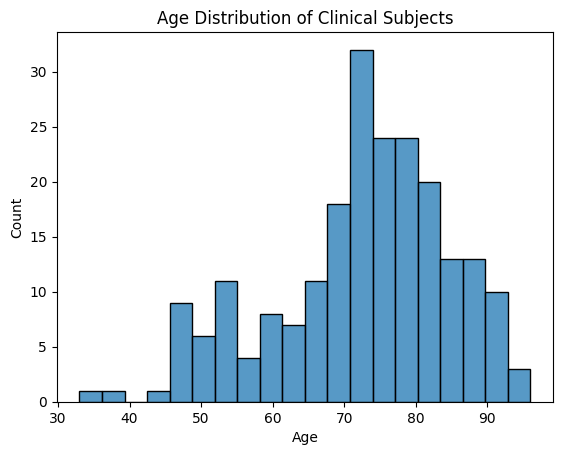

In [41]:
sns.histplot(data=df_clinical, x="Age", bins=20)
plt.title("Age Distribution of Clinical Subjects")
plt.show()

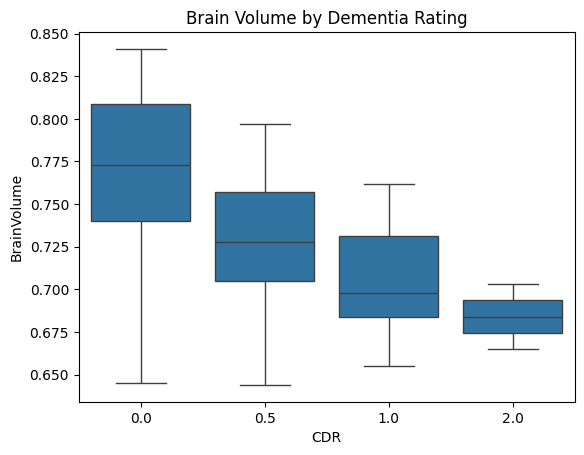

In [42]:
sns.boxplot(data=df_clinical, x="CDR", y="BrainVolume")
plt.title("Brain Volume by Dementia Rating")
plt.show()

# this visualizes what our groupby showed numerically:
# brain volume decreases as CDR increases

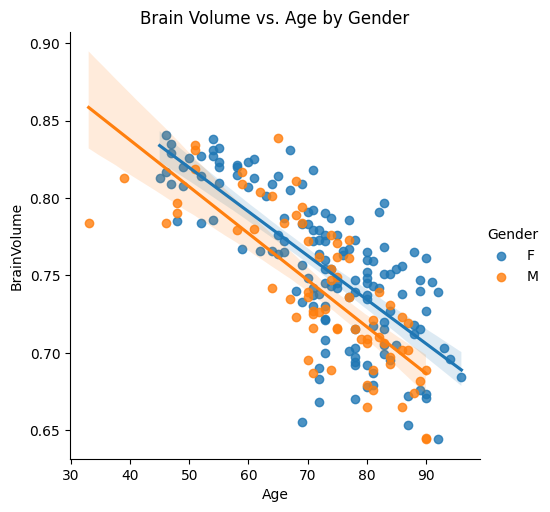

In [43]:
sns.lmplot(data=df_clinical, x="Age", y="BrainVolume", hue="Gender")
plt.title("Brain Volume vs. Age by Gender")
plt.show()

# one line of code gives us a scatterplot, regression lines, and a gender comparison
# that's the power of seaborn

# Wrap-up

Today we:
1. **Graduated** from Google Colab to a local Python development environment
2. **Loaded** real neuroscience data (OASIS-1) into pandas
3. **Inspected** the data with `info()`, `head()`, `describe()`
4. **Selected** data with bracket notation, `.loc[]`, and boolean filters
5. **Cleaned** the data by dropping columns, handling missing values, renaming, and converting types
6. **Answered a research question** using `groupby()`: brain volume decreases with dementia rating
7. **Visualized** our findings with seaborn

## Resources for Continued Learning

### pandas
- [pandas documentation](https://pandas.pydata.org/docs/)
- [pandas 10-minute intro](https://pandas.pydata.org/docs/user_guide/10min.html)
- [pandas cheat sheet (DataCamp)](https://www.datacamp.com/cheat-sheet/pandas-cheat-sheet-for-data-science-in-python)

### seaborn
- [seaborn tutorial](https://seaborn.pydata.org/tutorial.html)
- [seaborn gallery](https://seaborn.pydata.org/examples/index.html)

### Data Analysis with Python
- [LinkedIn Learning: Python Data Analysis](https://www.linkedin.com/learning/python-data-analysis-24296803)
- [Python Data Science Handbook (free online)](https://jakevdp.github.io/PythonDataScienceHandbook/)

### Yale Resources
- [Yale Library: Learn to Work with Data](https://library.medicine.yale.edu/research-data/learn-work-data)
- [Yale Center for Research Computing: Python Series](https://research.computing.yale.edu/training/python-series)

### Dataset
- **OASIS-1 Citation**: Marcus, D.S., Wang, T.H., Parker, J., Csernansky, J.G., Morris, J.C., Buckner, R.L. (2007). Open Access Series of Imaging Studies (OASIS): Cross-Sectional MRI Data in Young, Middle Aged, Nondemented and Demented Older Adults. *Journal of Cognitive Neuroscience*, 19(9), 1498-1507.
- [OASIS Brains](https://sites.wustl.edu/oasisbrains/)
- [Download from Kaggle](https://www.kaggle.com/datasets/jboysen/mri-and-alzheimers)

---

# Appendix: AI as a Pair Programmer

*(This section is a reference for self-study — it was not covered during the live session.)*

## What is AI pair programming?

AI coding assistants like [GitHub Copilot](https://github.com/features/copilot) and [Claude](https://claude.ai) can help you write, debug, and understand code. Think of them as a knowledgeable colleague who can suggest code, explain errors, and help you explore unfamiliar libraries.

## When is it useful?

- **Learning a new library**: "How do I make a grouped bar chart in seaborn?"
- **Debugging errors**: Paste an error message and ask what it means
- **Exploring data**: "Write pandas code to find the top 10 most common values in this column"
- **Understanding code**: "Explain what this groupby statement does"

## When should you be cautious?

- AI can generate plausible-looking code that is **wrong** — always verify output against your data
- AI doesn't know your specific dataset — it may suggest operations that don't apply
- AI-generated code may not follow best practices

## Example: Using AI for a pandas task

**Prompt**: "I have a pandas DataFrame with columns Age, Gender, CDR, and BrainVolume. Write code to create a summary table showing the mean brain volume for each CDR group, split by gender."

**AI-generated code**:
```python
summary = df_clinical.groupby(["CDR", "Gender"])["BrainVolume"].mean().unstack()
print(summary)
```

**Discussion questions to ask yourself**:
- Does this code produce what I asked for?
- What does `.unstack()` do? (Look it up in the [pandas docs](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.unstack.html)!)
- Would I have written this differently?
- Can I explain every part of this code to someone else?